In [ ]:
# CELL 1 - HEADER AND SETUP
# Notebook metadata, runtime banner, and project overview for the image classification task.

print("=" * 60)
print("6CS012 - VISION TASK: IMAGE CLASSIFICATION")
print("Running on Kaggle with GPU P100")
print("=" * 60)

6CS012 - VISION TASK: IMAGE CLASSIFICATION
Running on Kaggle with GPU P100


In [ ]:
# CELL 2 - IMPORTS
# Load Python libraries, configure TensorFlow, enable mixed precision, and fix random seeds for reproducibility.

import os
import random
import time
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, UnidentifiedImageError

# Load Python libraries, configure TensorFlow, and fix random seeds for reproducibility.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Enable Mixed Precision for faster training on GPU
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Mixed precision:", mixed_precision.global_policy())

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: <DTypePolicy "mixed_float16">


In [ ]:
# CELL 3 - COPY DATASET TO WORKING DIRECTORY
# Copy the flower dataset from the read-only Kaggle input directory to the writable working directory.

print("="*50)
print("COPYING DATASET TO WORKING DIRECTORY")
print("="*50)

# Source: Read-only Kaggle input (your uploaded dataset)
source_dataset = Path("/kaggle/input/datasets/khurshidabdulla/flower-classification/Flower Classification")

# Destination: Writable working directory
working_dataset = Path("/kaggle/working/Flower Classification")

print(f"Source: {source_dataset}")
print(f"Source exists: {source_dataset.exists()}")

if source_dataset.exists():
    if working_dataset.exists():
        shutil.rmtree(working_dataset)
    
    print("Copying dataset (this may take a moment)...")
    shutil.copytree(source_dataset, working_dataset)
    print(f"Copied to: {working_dataset}")
    
    train_dir = working_dataset / "Train"
    test_dir = working_dataset / "Test"
    
    print(f"\nTrain directory: {train_dir}")
    print(f"Train exists: {train_dir.exists()}")
    
    if train_dir.exists():
        class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
        NUM_CLASSES = len(class_names)
        print(f"Classes: {class_names}")
        print(f"Number of classes: {NUM_CLASSES}")
else:
    print("ERROR: Source dataset not found!")
    print("Checking alternative paths...")
    alt_path = Path("/kaggle/input/datasets/khurshidabdulla")
    if alt_path.exists():
        for item in alt_path.iterdir():
            print(f"  {item.name}")

# CELL 4: DATASET ANALYSIS AND CORRUPTED IMAGE REMOVAL
# Summarize dataset composition and remove unreadable images from the training set.
from PIL import UnidentifiedImageError

# Count images per class
train_class_counts = {}
train_total = 0

for cls_path in sorted(train_dir.iterdir()):
    if cls_path.is_dir():
        imgs = [f for f in cls_path.glob("*.*")
                if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        train_class_counts[cls_path.name] = len(imgs)
        train_total += len(imgs)

print("=" * 45)
print("        DATASET SUMMARY")
print("=" * 45)
print(f"Total Training Images : {train_total}")
print(f"Number of Classes     : {len(train_class_counts)}")
print("=" * 45)
print("\nClass Distribution (Training):")
print("-" * 45)
for cls, count in train_class_counts.items():
    bar = "█" * (count // 50)
    print(f"  {cls:<12}: {count:>4} images ({count/train_total*100:.1f}%)  {bar}")
print("-" * 45)

# Scan and remove corrupted images
print("\nScanning for corrupted images...")
corrupted = []
total_scanned = 0

for cls_path in sorted(train_dir.iterdir()):
    if not cls_path.is_dir():
        continue
    cls_corrupted = 0
    for img_path in cls_path.glob("*.*"):
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue
        total_scanned += 1
        try:
            img = Image.open(img_path)
            img.verify()
        except (UnidentifiedImageError, Exception):
            corrupted.append(img_path)
            cls_corrupted += 1
    if cls_corrupted > 0:
        print(f"  {cls_path.name}: {cls_corrupted} corrupted")

print(f"\nTotal scanned: {total_scanned}")
print(f"Total corrupted: {len(corrupted)}")

if corrupted:
    print(f"\nRemoving {len(corrupted)} corrupted images...")
    for f in corrupted:
        try:
            if f.exists():
                f.unlink()
                print(f"  Deleted: {f.name}")
        except Exception as e:
            pass
    
    # Recount after cleaning
    train_class_counts = {}
    train_total = 0
    for cls_path in sorted(train_dir.iterdir()):
        if cls_path.is_dir():
            imgs = [f for f in cls_path.glob("*.*")
                    if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
            train_class_counts[cls_path.name] = len(imgs)
            train_total += len(imgs)
    
    print("\nUpdated class counts after cleaning:")
    for cls, count in train_class_counts.items():
        print(f"  {cls:<12}: {count} images")
    print(f"Total clean images: {train_total}")
else:
    print("No corrupted images found. Dataset is clean.")

COPYING DATASET TO WORKING DIRECTORY
Source: /kaggle/input/datasets/khurshidabdulla/flower-classification/Flower Classification
Source exists: True
Copying dataset (this may take a moment)...
Copied to: /kaggle/working/Flower Classification

Train directory: /kaggle/working/Flower Classification/Train
Train exists: True
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [ ]:
# CELL 4 - DATASET ANALYSIS AND CORRUPTED IMAGE REMOVAL
# Summarize dataset class distribution and scan for and remove unreadable or corrupted images.

from PIL import UnidentifiedImageError

# Count images per class
train_class_counts = {}
train_total = 0

for cls_path in sorted(train_dir.iterdir()):
    if cls_path.is_dir():
        imgs = [f for f in cls_path.glob("*.*")
                if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        train_class_counts[cls_path.name] = len(imgs)
        train_total += len(imgs)

print("=" * 45)
print("        DATASET SUMMARY")
print("=" * 45)
print(f"Total Training Images : {train_total}")
print(f"Number of Classes     : {len(train_class_counts)}")
print("=" * 45)
print("\nClass Distribution (Training):")
print("-" * 45)
for cls, count in train_class_counts.items():
    bar = "█" * (count // 50)
    print(f"  {cls:<12}: {count:>4} images ({count/train_total*100:.1f}%)  {bar}")
print("-" * 45)

# Scan and remove corrupted images
print("\nScanning for corrupted images...")
corrupted = []
total_scanned = 0

for cls_path in sorted(train_dir.iterdir()):
    if not cls_path.is_dir():
        continue
    cls_corrupted = 0
    for img_path in cls_path.glob("*.*"):
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue
        total_scanned += 1
        try:
            img = Image.open(img_path)
            img.verify()
        except (UnidentifiedImageError, Exception):
            corrupted.append(img_path)
            cls_corrupted += 1
    if cls_corrupted > 0:
        print(f"  {cls_path.name}: {cls_corrupted} corrupted")

print(f"\nTotal scanned: {total_scanned}")
print(f"Total corrupted: {len(corrupted)}")

if corrupted:
    print(f"\nRemoving {len(corrupted)} corrupted images...")
    for f in corrupted:
        try:
            if f.exists():
                f.unlink()
                print(f"  Deleted: {f.name}")
        except Exception as e:
            pass
    
    # Recount after cleaning
    train_class_counts = {}
    train_total = 0
    for cls_path in sorted(train_dir.iterdir()):
        if cls_path.is_dir():
            imgs = [f for f in cls_path.glob("*.*")
                    if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
            train_class_counts[cls_path.name] = len(imgs)
            train_total += len(imgs)
    
    print("\nUpdated class counts after cleaning:")
    for cls, count in train_class_counts.items():
        print(f"  {cls:<12}: {count} images")
    print(f"Total clean images: {train_total}")
else:
    print("No corrupted images found. Dataset is clean.")

        DATASET SUMMARY
Total Training Images : 4312
Number of Classes     : 5

Class Distribution (Training):
---------------------------------------------
  daisy       :  763 images (17.7%)  ███████████████
  dandelion   : 1051 images (24.4%)  █████████████████████
  rose        :  783 images (18.2%)  ███████████████
  sunflower   :  732 images (17.0%)  ██████████████
  tulip       :  983 images (22.8%)  ███████████████████
---------------------------------------------

Scanning for corrupted images...
  daisy: 7 corrupted
  dandelion: 7 corrupted
  rose: 7 corrupted
  sunflower: 7 corrupted
  tulip: 7 corrupted

Total scanned: 4312
Total corrupted: 35

Removing 35 corrupted images...
  Deleted: 3475870145_685a19116d.jpg
  Deleted: 33884228533_91b75ff4d4_n.jpg
  Deleted: 2908212142_5437fa67ff_n.jpg
  Deleted: 34532930772_5cc5fc600d_n.jpg
  Deleted: 33880234094_2541c9c83d_n.jpg
  Deleted: 2536529152_33ef3ee078_n.jpg
  Deleted: 4563059851_45a9d21a75.jpg
  Deleted: 17075803866_aeeded26

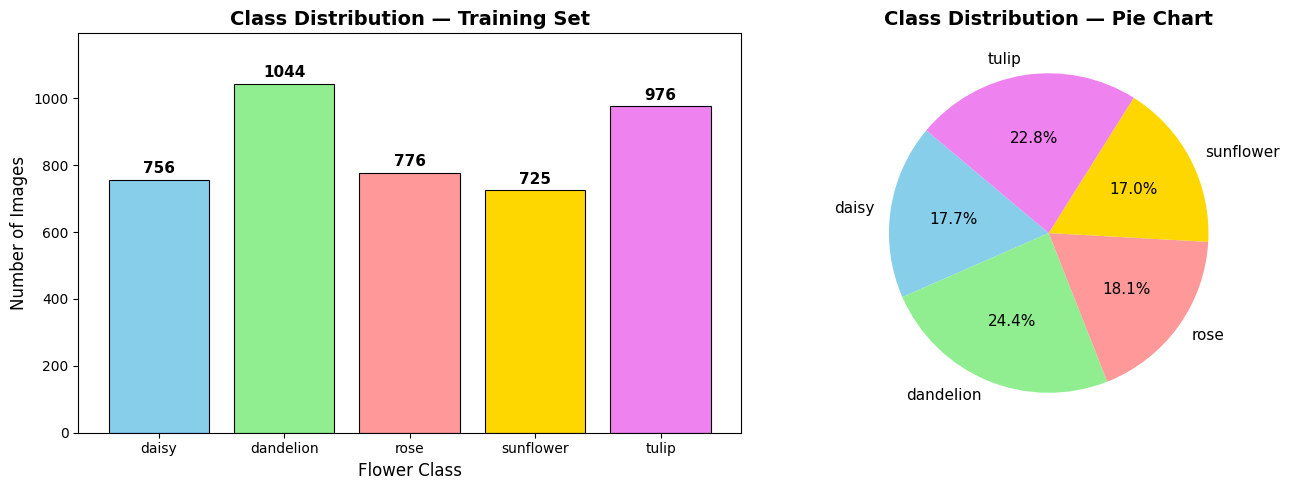

Chart saved as class_distribution.png


In [ ]:
# CELL 4.5 - BAR CHART AND PIE CHART VISUALIZATION
# Plot a bar chart and pie chart showing the class distribution of the training dataset.

classes = list(train_class_counts.keys())
counts = list(train_class_counts.values())
colors = ['#87CEEB', '#90EE90', '#FF9999', '#FFD700', '#EE82EE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(classes, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution — Training Set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Flower Class', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_ylim(0, max(counts) + 150)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(count), ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=classes, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution — Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as class_distribution.png")

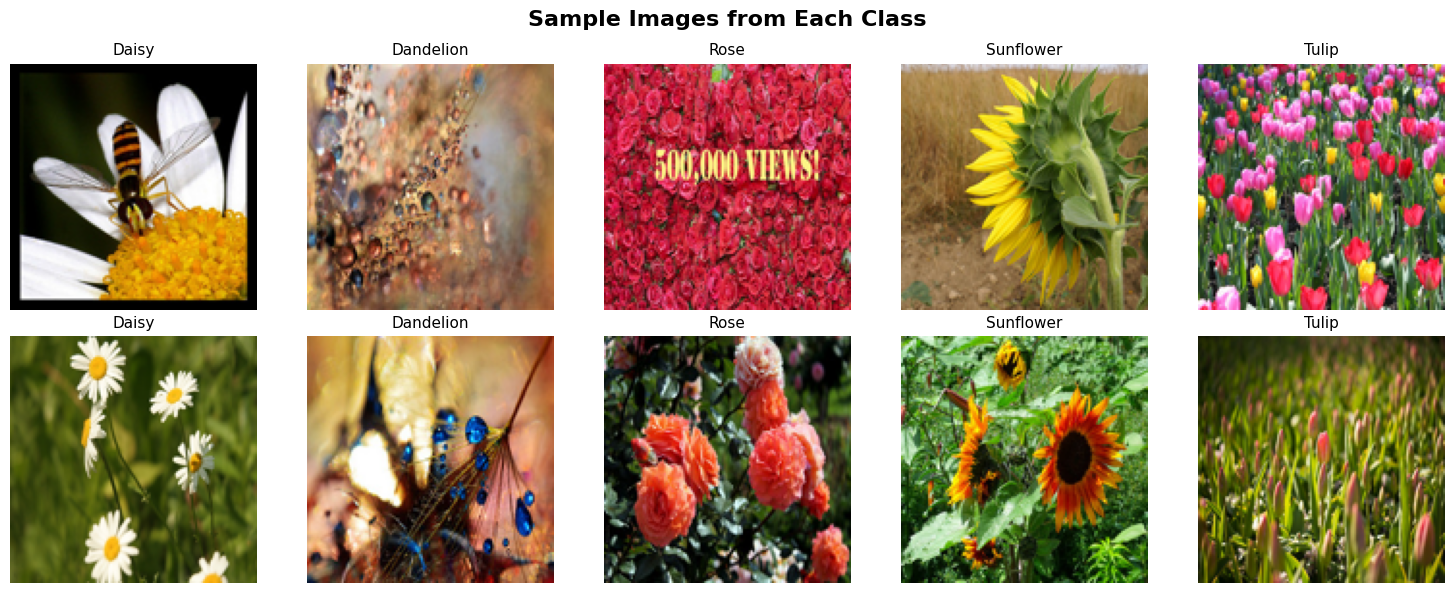

Chart saved as sample_images.png


In [ ]:
# CELL 4.6 - SAMPLE IMAGES FROM EACH CLASS
# Display two sample images per class to inspect visual variation and image quality.

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for col, (cls_name, _) in enumerate(train_class_counts.items()):
    cls_path = train_dir / cls_name
    img_files = [f for f in cls_path.glob("*.*")
                 if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    
    if img_files:  # Check if list is not empty
        for row in range(2):
            try:
                img = Image.open(random.choice(img_files)).resize((128, 128))
                axes[row, col].imshow(img)
                axes[row, col].set_title(cls_name.capitalize(), fontsize=11)
                axes[row, col].axis('off')
            except Exception as e:
                print(f"Error loading image for {cls_name}: {e}")
                axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as sample_images.png")

In [67]:
# CELL 5 - DATA AUGMENTATION AND BALANCING
# Apply augmentation transforms and balance each class to a fixed target count using generated images.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)
target_per_class = 1500

augmented_train_dir = Path("/kaggle/working/Augmented_Train")

# Setup augmentation generator
aug_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Check if already done
already_done = False
if augmented_train_dir.exists():
    counts_check = {}
    for cls_path in augmented_train_dir.iterdir():
        if cls_path.is_dir():
            n = len([f for f in cls_path.glob("*.*")
                     if f.suffix.lower() in ['.jpg','.jpeg','.png']])
            counts_check[cls_path.name] = n
    if len(counts_check) == NUM_CLASSES and all(v >= target_per_class for v in counts_check.values()):
        already_done = True
        print("Augmented dataset already exists and is balanced. Skipping.")
        for cls, cnt in counts_check.items():
            print(f"  {cls:<12}: {cnt} images")

if not already_done:
    if augmented_train_dir.exists():
        shutil.rmtree(augmented_train_dir)
    augmented_train_dir.mkdir(parents=True)
    print("Starting augmentation...\n")

    for cls_name, original_count in train_class_counts.items():
        cls_src = train_dir / cls_name
        cls_dest = augmented_train_dir / cls_name
        cls_dest.mkdir()

        # Get all original images
        orig_imgs = [f for f in cls_src.glob("*.*")
                     if f.suffix.lower() in ['.jpg','.jpeg','.png']]

        # Copy originals first
        for img_path in orig_imgs:
            shutil.copy(img_path, cls_dest / img_path.name)

        # Generate extra images to reach target
        needed = target_per_class - original_count
        generated = 0

        for i in range(needed):
            src_path = random.choice(orig_imgs)
            img = keras.utils.load_img(src_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            x = keras.utils.img_to_array(img).astype('float32')
            x_aug = aug_datagen.random_transform(x)
            aug_img = Image.fromarray(np.clip(x_aug, 0, 255).astype('uint8'))
            aug_img.save(cls_dest / f"aug_{cls_name}_{i:04d}.jpeg")
            generated += 1

        total = original_count + generated
        print(f"  {cls_name:<12}: {original_count} original + {generated} augmented = {total} total")

    print("\nAugmentation complete!")

Augmented dataset already exists and is balanced. Skipping.
  rose        : 1500 images
  sunflower   : 1500 images
  dandelion   : 1500 images
  tulip       : 1500 images
  daisy       : 1500 images


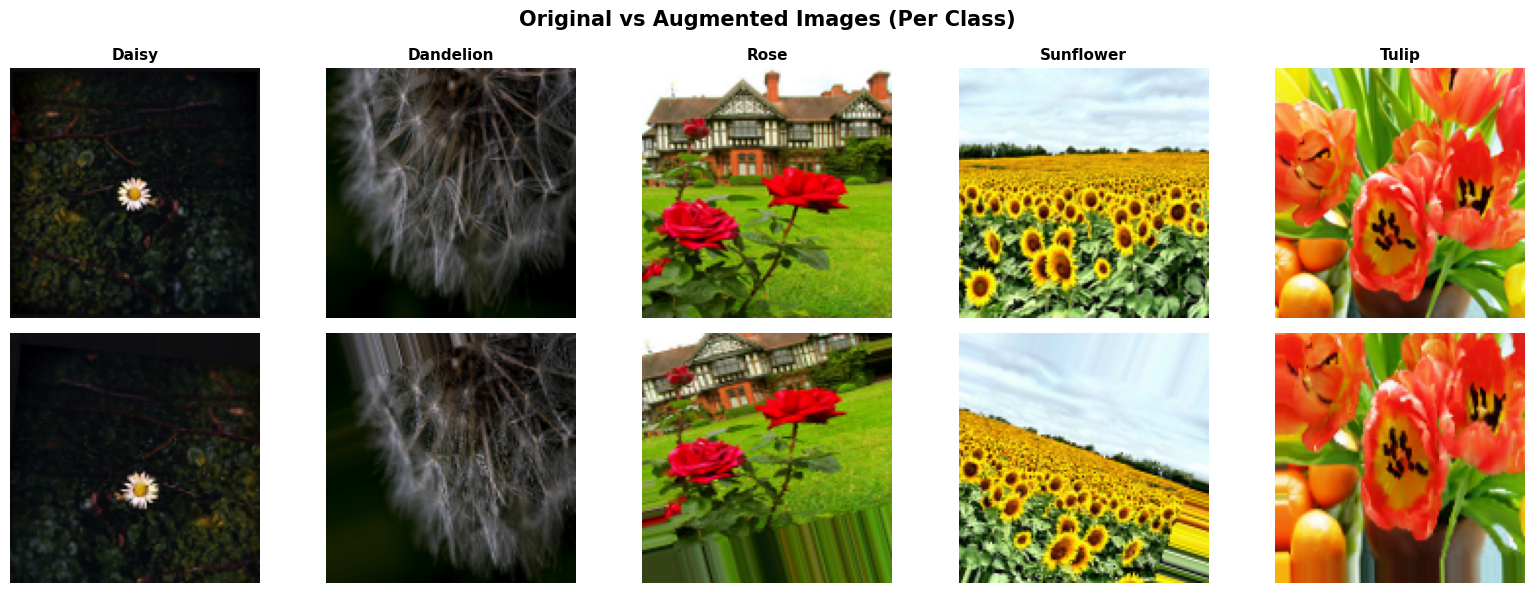

Saved as augmentation_comparison.png


In [68]:
# CELL 5.5 - ORIGINAL VS AUGMENTED IMAGES VISUALIZATION
# Visualize original images alongside their augmented counterparts for each class.

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 6))
fig.suptitle('Original vs Augmented Images (Per Class)', fontsize=15, fontweight='bold')

aug_demo = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.2,
    zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)

for col, cls_name in enumerate(sorted(train_class_counts.keys())):
    cls_path = train_dir / cls_name
    img_files = [f for f in cls_path.glob("*.*")
                 if f.suffix.lower() in ['.jpg','.jpeg','.png']]
    
    if img_files:
        chosen = random.choice(img_files)

        # Original
        try:
            orig = Image.open(chosen).resize((IMG_HEIGHT, IMG_WIDTH))
            axes[0, col].imshow(orig)
            axes[0, col].set_title(cls_name.capitalize(), fontsize=11, fontweight='bold')
            axes[0, col].set_ylabel('Original' if col == 0 else '', fontsize=10)
            axes[0, col].axis('off')
        except Exception as e:
            axes[0, col].axis('off')

        # Augmented
        try:
            x = keras.utils.img_to_array(
                keras.utils.load_img(chosen, target_size=(IMG_HEIGHT, IMG_WIDTH))
            ).astype('float32')
            x_aug = aug_demo.random_transform(x)
            axes[1, col].imshow(np.clip(x_aug, 0, 255).astype('uint8'))
            axes[1, col].set_ylabel('Augmented' if col == 0 else '', fontsize=10)
            axes[1, col].axis('off')
        except Exception as e:
            axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as augmentation_comparison.png")

In [69]:
# CELL 6 - TRAIN AND VALIDATION GENERATORS
# Create ImageDataGenerator flows for the augmented training and validation splits.

aug_datagen_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = aug_datagen_gen.flow_from_directory(
    augmented_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    seed=42,
    shuffle=True
)

val_gen = aug_datagen_gen.flow_from_directory(
    augmented_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    seed=42,
    shuffle=False
)

print("Class indices    :", train_gen.class_indices)
print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Training batches  : {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")

Found 6000 images belonging to 5 classes.
Found 1500 images belonging to 5 classes.
Class indices    : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Training samples  : 6000
Validation samples: 1500
Training batches  : 188
Validation batches: 47


In [70]:
# CELL 7 - BASELINE CNN MODEL
# Define a simple baseline CNN architecture with two convolutional blocks and a dense classifier.

baseline_model = keras.Sequential([
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Baseline_CNN")

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

I0000 00:00:1778423220.294252      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# CELL 8 - TRAIN BASELINE MODEL
# Set up early stopping and train the baseline CNN, measuring total training duration.

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the baseline CNN and measure the training duration
print("Training Baseline Model...\n")
start_time = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[early_stop],
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nTotal training time: {baseline_train_time/60:.2f} minutes")

Training Baseline Model...

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1778423237.736709     124 service.cc:152] XLA service 0x7e760400fb50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778423237.736763     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778423238.295856     124 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778423250.090163     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


188/188 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.3706 - loss: 1.4165 - val_accuracy: 0.5527 - val_loss: 1.0731
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.6006 - loss: 1.0020 - val_accuracy: 0.5787 - val_loss: 1.0253
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.6861 - loss: 0.8308 - val_accuracy: 0.6853 - val_loss: 0.8109
Epoch 4/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.7648 - loss: 0.6248 - val_accuracy: 0.6933 - val_loss: 0.8369
Epoch 5/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.8491 - loss: 0.4101 - val_accuracy: 0.6673 - val_loss: 1.0578
Epoch 6/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9016 - loss: 0.2767 - val_accuracy: 0.6773 - val_loss: 1.2544
Epoch 7/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9394 - loss: 0.1757 - val_accuracy: 0.6933 - val_loss: 1.4831
Epoch 8/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9647 - loss: 0.1168 - val_accuracy: 0.6

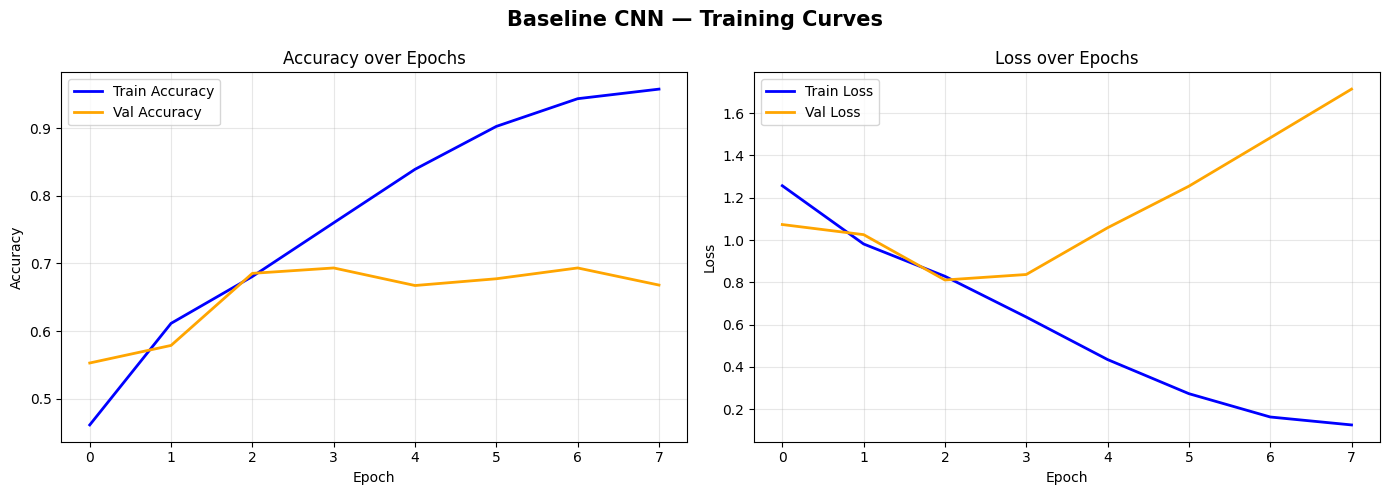

In [72]:
# CELL 9 - PLOT TRAINING CURVES
# Helper function to plot accuracy and loss curves for any trained model.

def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training Curves', fontsize=15, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue',   linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange', linewidth=2)
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='blue',   linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange', linewidth=2)
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(baseline_history, 'Baseline CNN')

In [74]:
# CELL 10 - EVALUATE BASELINE MODEL
# Generate predictions on the validation set and print the classification report for the baseline CNN.

val_gen.reset()
y_pred_probs = baseline_model.predict(val_gen, verbose=1)
y_pred  = np.argmax(y_pred_probs, axis=1)
y_true  = val_gen.classes
class_names = list(train_gen.class_indices.keys())

print("=" * 55)
print("     BASELINE MODEL — EVALUATION REPORT")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=class_names))

val_loss, val_acc = baseline_model.evaluate(val_gen, verbose=0)
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Training Time       : {baseline_train_time/60:.2f} minutes")

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step
     BASELINE MODEL — EVALUATION REPORT
              precision    recall  f1-score   support

       daisy       0.72      0.75      0.73       300
   dandelion       0.79      0.63      0.70       300
        rose       0.59      0.61      0.60       300
   sunflower       0.74      0.82      0.78       300
       tulip       0.61      0.62      0.61       300

    accuracy                           0.69      1500
   macro avg       0.69      0.69      0.68      1500
weighted avg       0.69      0.69      0.68      1500

Validation Accuracy : 68.53%
Validation Loss     : 0.8109
Training Time       : 1.65 minutes


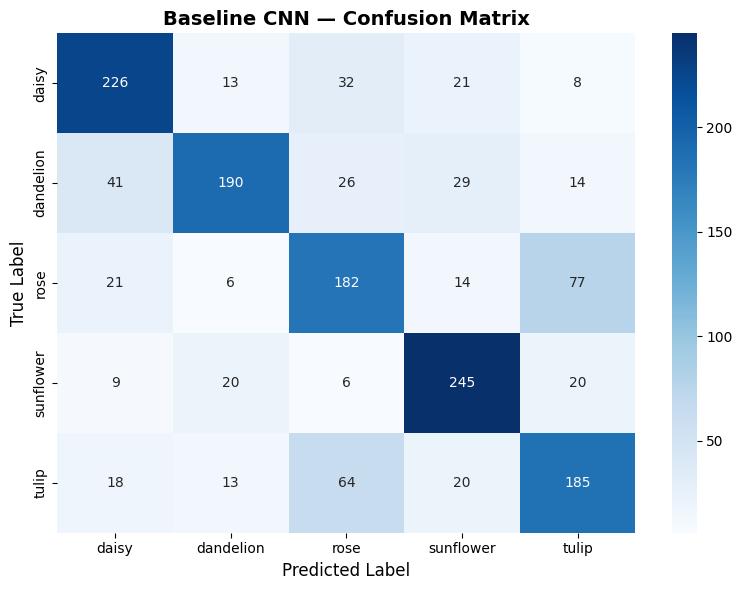

In [75]:
# CELL 11 - CONFUSION MATRIX FOR BASELINE MODEL
# Plot the confusion matrix heatmap for the baseline CNN model predictions.

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Baseline CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

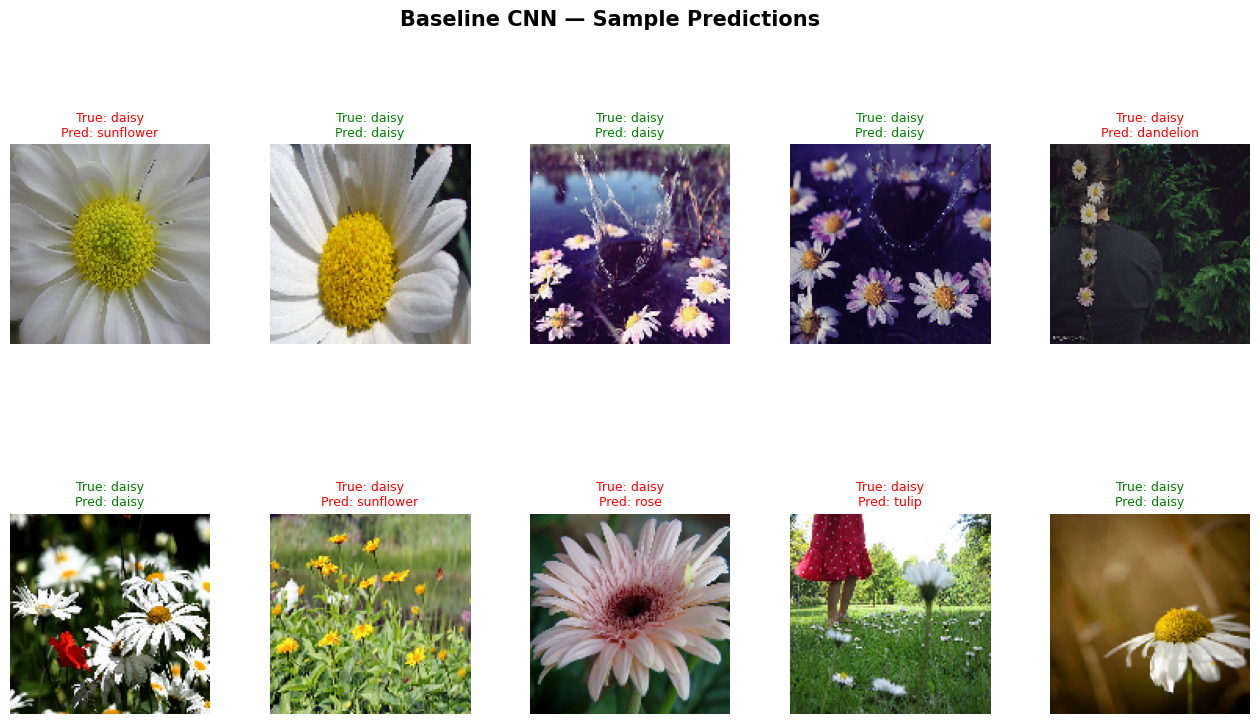

In [ ]:
# CELL 12 - SAMPLE PREDICTIONS FOR BASELINE MODEL
# Visualise a batch of validation images with their true and predicted labels for the baseline CNN.

val_gen.reset()
images, labels = next(val_gen)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('Baseline CNN — Sample Predictions', fontsize=15, fontweight='bold', y=1.02)

for i, ax in enumerate(axes.flat):
    img  = images[i]
    true = class_names[int(labels[i])]
    pred = class_names[np.argmax(baseline_model.predict(img[np.newaxis,...], verbose=0))]
    color = 'green' if true == pred else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true}\nPred: {pred}', color=color, fontsize=9, pad=6)
    ax.axis('off')

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

In [77]:
# CELL 13 - DEEPER CNN MODEL
# Define a deeper CNN with five convolutional blocks, batch normalisation, dropout, and global average pooling.

deeper_model = keras.Sequential([
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 5
    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Global Average Pooling instead of Flatten
    layers.GlobalAveragePooling2D(),

    # FCN Layers
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="Deeper_CNN")

deeper_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,788,901 (10.64 MB)

 Trainable params: 2,784,421 (10.62 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [78]:
# CELL 14 - TRAIN DEEPER MODEL
# Train the deeper CNN with early stopping and a model checkpoint callback.

print("Training Deeper Model...\n")

early_stop_deep = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

checkpoint_deep = ModelCheckpoint(
    '/content/drive/MyDrive/Ai and Machine Learning/Assessment/deeper_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

start_time_deep = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=[early_stop_deep, checkpoint_deep],
    verbose=1
)

deeper_train_time = time.time() - start_time_deep
print(f"\nTotal training time: {deeper_train_time/60:.2f} minutes")

Training Deeper Model...

Epoch 1/40
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.3057 - loss: 2.1696
Epoch 1: val_accuracy improved from -inf to 0.20000, saving model to /content/drive/MyDrive/Ai and Machine Learning/Assessment/deeper_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 75s 217ms/step - accuracy: 0.3063 - loss: 2.1661 - val_accuracy: 0.2000 - val_loss: 4.5666
Epoch 2/40
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4400 - loss: 1.4149
Epoch 2: val_accuracy improved from 0.20000 to 0.29333, saving model to /content/drive/MyDrive/Ai and Machine Learning/Assessment/deeper_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.4401 - loss: 1.4142 - val_accuracy: 0.2933 - val_loss: 1.9687
Epoch 3/40
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5072 - loss: 1.2480
Epoch 3: val_accuracy improved from 0.29333 to 0.48600, saving model to /content/drive/MyDrive/Ai and Machine Learning/Assessment/deeper_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s

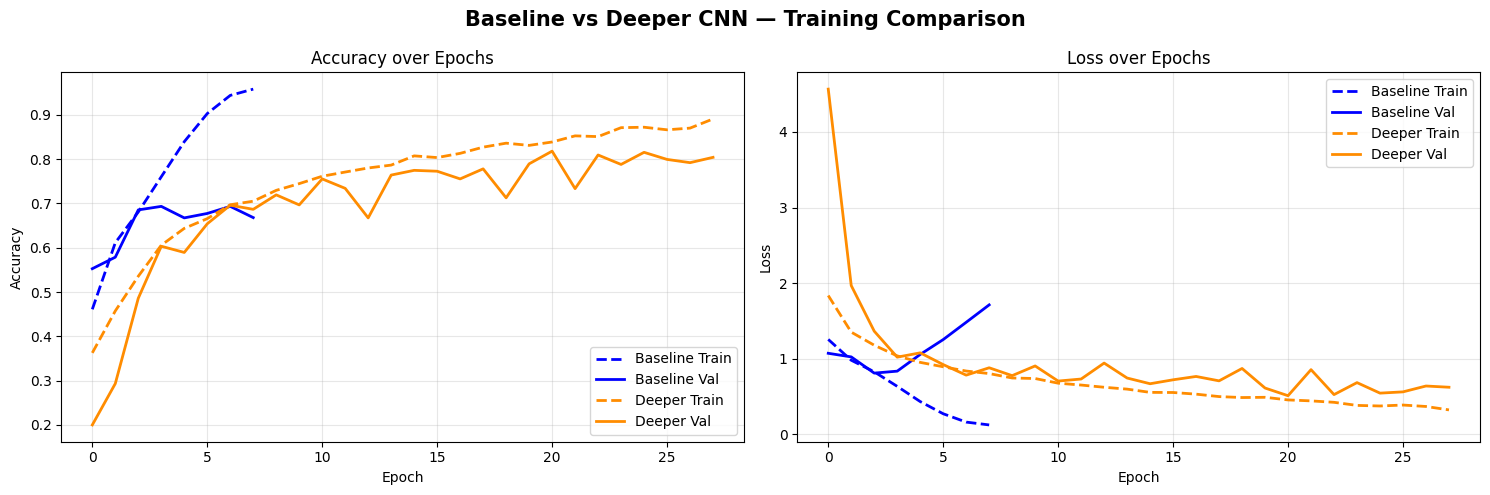

In [79]:
# CELL 15 - COMPARE BASELINE VS DEEPER TRAINING CURVES
# Plot accuracy and loss curves side by side for the baseline and deeper CNN models.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Baseline vs Deeper CNN — Training Comparison', fontsize=15, fontweight='bold')

# Accuracy
axes[0].plot(baseline_history.history['accuracy'],     label='Baseline Train', color='blue',      linewidth=2, linestyle='--')
axes[0].plot(baseline_history.history['val_accuracy'], label='Baseline Val',   color='blue',      linewidth=2)
axes[0].plot(deeper_history.history['accuracy'],       label='Deeper Train',   color='darkorange', linewidth=2, linestyle='--')
axes[0].plot(deeper_history.history['val_accuracy'],   label='Deeper Val',     color='darkorange', linewidth=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(baseline_history.history['loss'],     label='Baseline Train', color='blue',      linewidth=2, linestyle='--')
axes[1].plot(baseline_history.history['val_loss'], label='Baseline Val',   color='blue',      linewidth=2)
axes[1].plot(deeper_history.history['loss'],       label='Deeper Train',   color='darkorange', linewidth=2, linestyle='--')
axes[1].plot(deeper_history.history['val_loss'],   label='Deeper Val',     color='darkorange', linewidth=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [80]:
# CELL 16 - EVALUATE DEEPER MODEL
# Generate predictions on the validation set and print the classification report for the deeper CNN.

val_gen.reset()
y_pred_probs_deep = deeper_model.predict(val_gen, verbose=1)
y_pred_deep = np.argmax(y_pred_probs_deep, axis=1)
y_true_deep = val_gen.classes

print("=" * 55)
print("     DEEPER MODEL — EVALUATION REPORT")
print("=" * 55)
print(classification_report(y_true_deep, y_pred_deep, target_names=class_names))

val_loss_deep, val_acc_deep = deeper_model.evaluate(val_gen, verbose=0)
print(f"Validation Accuracy : {val_acc_deep*100:.2f}%")
print(f"Validation Loss     : {val_loss_deep:.4f}")
print(f"Training Time       : {deeper_train_time/60:.2f} minutes")

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step
     DEEPER MODEL — EVALUATION REPORT
              precision    recall  f1-score   support

       daisy       0.94      0.82      0.88       300
   dandelion       0.80      0.85      0.82       300
        rose       0.67      0.89      0.77       300
   sunflower       0.87      0.92      0.89       300
       tulip       0.90      0.61      0.73       300

    accuracy                           0.82      1500
   macro avg       0.84      0.82      0.82      1500
weighted avg       0.84      0.82      0.82      1500

Validation Accuracy : 81.80%
Validation Loss     : 0.5121
Training Time       : 5.54 minutes


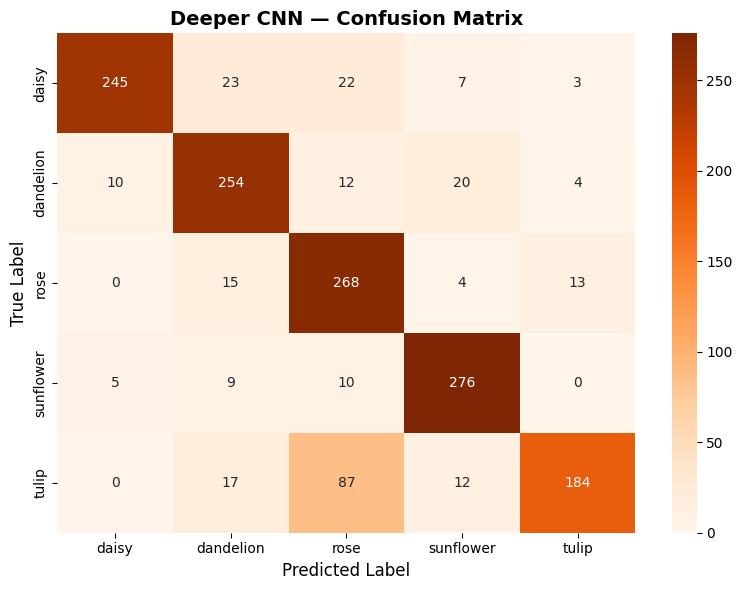

In [81]:
# CELL 17 - CONFUSION MATRIX FOR DEEPER MODEL
# Plot the confusion matrix heatmap for the deeper CNN model predictions.

cm_deep = confusion_matrix(y_true_deep, y_pred_deep)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Deeper CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('deeper_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

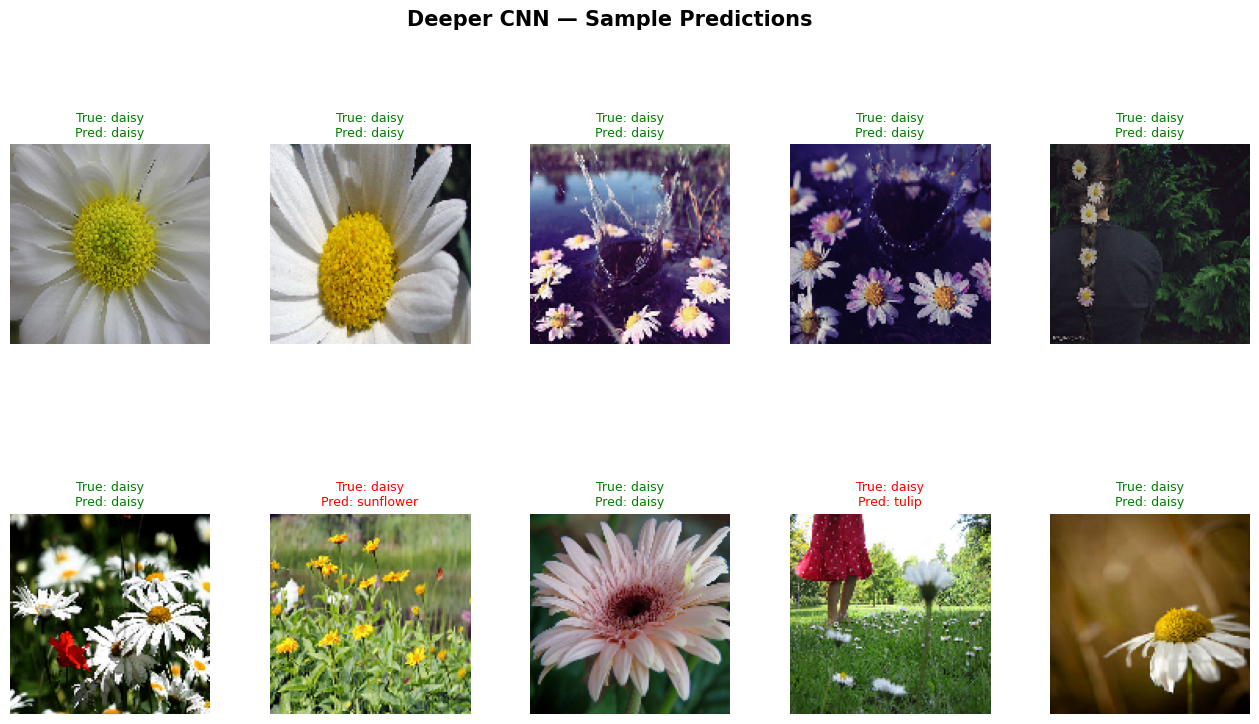

In [82]:
# CELL 18 - SAMPLE PREDICTIONS FOR DEEPER MODEL
# Visualise a batch of validation images with true and predicted labels for the deeper CNN.

val_gen.reset()
images, labels = next(val_gen)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('Deeper CNN — Sample Predictions', fontsize=15, fontweight='bold', y=1.02)

for i, ax in enumerate(axes.flat):
    img  = images[i]
    true = class_names[int(labels[i])]
    pred = class_names[np.argmax(deeper_model.predict(img[np.newaxis,...], verbose=0))]
    color = 'green' if true == pred else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true}\nPred: {pred}', color=color, fontsize=9, pad=6)
    ax.axis('off')

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

In [83]:
# CELL 19 - SGD VS ADAM EXPERIMENT
# Build and train two identical deeper CNN models using SGD and Adam optimisers for comparison.

def build_deeper_model():
    model = keras.Sequential([
        keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# Train with SGD
model_sgd = build_deeper_model()
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training with SGD...\n")
start_sgd = time.time()

history_sgd = model_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

sgd_train_time = time.time() - start_sgd
val_loss_sgd, val_acc_sgd = model_sgd.evaluate(val_gen, verbose=0)
print(f"\nSGD — Val Accuracy: {val_acc_sgd*100:.2f}% | Val Loss: {val_loss_sgd:.4f} | Time: {sgd_train_time/60:.2f} min")

# Train with Adam
model_adam = build_deeper_model()
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining with Adam...\n")
start_adam = time.time()

history_adam = model_adam.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

adam_train_time = time.time() - start_adam
val_loss_adam, val_acc_adam = model_adam.evaluate(val_gen, verbose=0)
print(f"\nAdam — Val Accuracy: {val_acc_adam*100:.2f}% | Val Loss: {val_loss_adam:.4f} | Time: {adam_train_time/60:.2f} min")

Training with SGD...

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 107ms/step - accuracy: 0.3230 - loss: 1.8800 - val_accuracy: 0.3973 - val_loss: 1.3696
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.4721 - loss: 1.2778 - val_accuracy: 0.5080 - val_loss: 1.1959
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.4994 - loss: 1.1959 - val_accuracy: 0.5333 - val_loss: 1.2413
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.5546 - loss: 1.1180 - val_accuracy: 0.5407 - val_loss: 1.1341
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.5905 - loss: 1.0459 - val_accuracy: 0.6307 - val_loss: 0.9962
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.6136 - loss: 0.9976 - val_accuracy: 0.6233 - val_loss: 1.0177
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.6343 - loss: 0.9401 - val_accuracy: 0.6727 - val_loss: 0.8638
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.6545 -

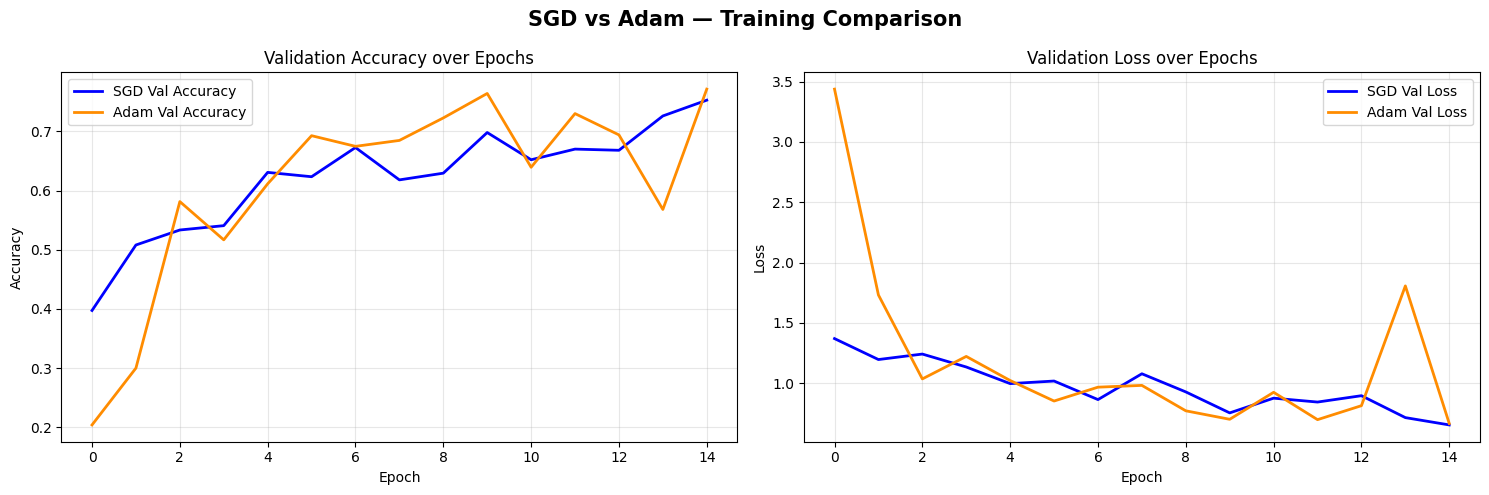

In [84]:
# CELL 20 - SGD VS ADAM COMPARISON PLOT
# Plot validation accuracy and loss curves for the SGD and Adam optimiser experiments side by side.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('SGD vs Adam — Training Comparison', fontsize=15, fontweight='bold')

axes[0].plot(history_sgd.history['val_accuracy'],  label='SGD Val Accuracy',  color='blue',   linewidth=2)
axes[0].plot(history_adam.history['val_accuracy'], label='Adam Val Accuracy', color='darkorange', linewidth=2)
axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_sgd.history['val_loss'],  label='SGD Val Loss',  color='blue',   linewidth=2)
axes[1].plot(history_adam.history['val_loss'], label='Adam Val Loss', color='darkorange', linewidth=2)
axes[1].set_title('Validation Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [85]:
# CELL 21 - SGD AND ADAM EVALUATION REPORTS
# Print classification reports for both the SGD-trained and Adam-trained models.

val_gen.reset()
y_pred_sgd = np.argmax(model_sgd.predict(val_gen, verbose=0), axis=1)
print("SGD — Classification Report")
print(classification_report(val_gen.classes, y_pred_sgd, target_names=class_names))

# Adam Evaluation
val_gen.reset()
y_pred_adam = np.argmax(model_adam.predict(val_gen, verbose=0), axis=1)
print("Adam — Classification Report")
print(classification_report(val_gen.classes, y_pred_adam, target_names=class_names))

SGD — Classification Report
              precision    recall  f1-score   support

       daisy       0.80      0.82      0.81       300
   dandelion       0.63      0.88      0.74       300
        rose       0.71      0.71      0.71       300
   sunflower       0.85      0.79      0.82       300
       tulip       0.85      0.57      0.68       300

    accuracy                           0.75      1500
   macro avg       0.77      0.75      0.75      1500
weighted avg       0.77      0.75      0.75      1500

Adam — Classification Report
              precision    recall  f1-score   support

       daisy       0.91      0.82      0.86       300
   dandelion       0.63      0.89      0.74       300
        rose       0.75      0.69      0.72       300
   sunflower       0.89      0.79      0.84       300
       tulip       0.77      0.66      0.71       300

    accuracy                           0.77      1500
   macro avg       0.79      0.77      0.77      1500
weighted avg       0

In [87]:
# CELL 22 - ABLATION STUDY: REMOVE DROPOUT
# Build, train, and evaluate a deeper CNN without dropout layers to measure the effect of regularisation.

def build_ablation_model():
    model = keras.Sequential([
        keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # Conv Block 1 — No Dropout
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 2 — No Dropout
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 3 — No Dropout
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 4 — No Dropout
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.GlobalAveragePooling2D(),

        # FCN — No Dropout
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),

        layers.Dense(128, activation='relu'),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name="Ablation_No_Dropout")

    return model

# Build & Compile
model_ablation = build_ablation_model()
model_ablation.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_ablation.summary()

# Train
print("\nTraining Ablation Model (No Dropout)...\n")
start_ablation = time.time()

history_ablation = model_ablation.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

ablation_train_time = time.time() - start_ablation

# Evaluate
val_gen.reset()
y_pred_ablation = np.argmax(model_ablation.predict(val_gen, verbose=0), axis=1)

val_loss_abl, val_acc_abl = model_ablation.evaluate(val_gen, verbose=0)

print("=" * 55)
print("   ABLATION MODEL (No Dropout) — EVALUATION REPORT")
print("=" * 55)
print(classification_report(val_gen.classes, y_pred_ablation, target_names=class_names))
print(f"Validation Accuracy : {val_acc_abl*100:.2f}%")
print(f"Validation Loss     : {val_loss_abl:.4f}")
print(f"Training Time       : {ablation_train_time/60:.2f} minutes")

Model: "Ablation_No_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 256)            │         1,02

 Total params: 685,349 (2.61 MB)

 Trainable params: 683,429 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)


Training Ablation Model (No Dropout)...

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.4460 - loss: 1.3887 - val_accuracy: 0.1893 - val_loss: 2.2427
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6165 - loss: 0.9781 - val_accuracy: 0.3460 - val_loss: 1.6503
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6614 - loss: 0.8690 - val_accuracy: 0.6460 - val_loss: 0.9993
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7040 - loss: 0.7796 - val_accuracy: 0.6707 - val_loss: 1.1119
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.7218 - loss: 0.7145 - val_accuracy: 0.6073 - val_loss: 1.0812
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7539 - loss: 0.6701 - val_accuracy: 0.6453 - val_loss: 1.0087
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.7606 - loss: 0.6469 - val_accuracy: 0.7207 - val_loss: 0.7206
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step

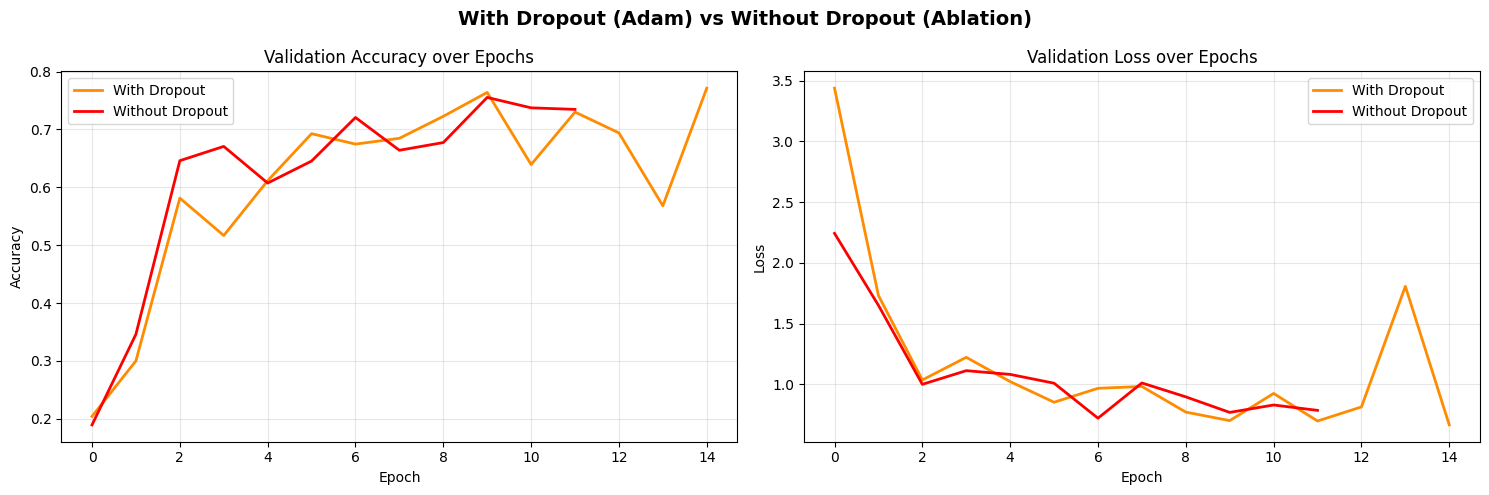

In [88]:
# CELL 23 - ABLATION VS ADAM COMPARISON PLOT
# Compare validation accuracy and loss for the model with dropout (Adam) against the ablation model without dropout.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('With Dropout (Adam) vs Without Dropout (Ablation)',
             fontsize=14, fontweight='bold')

axes[0].plot(history_adam.history['val_accuracy'],
             label='With Dropout', color='darkorange', linewidth=2)
axes[0].plot(history_ablation.history['val_accuracy'],
             label='Without Dropout', color='red', linewidth=2)
axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_adam.history['val_loss'],
             label='With Dropout', color='darkorange', linewidth=2)
axes[1].plot(history_ablation.history['val_loss'],
             label='Without Dropout', color='red', linewidth=2)
axes[1].set_title('Validation Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [91]:
# CELL 24 - TRANSFER LEARNING SETUP: VGG16
# Configure image generators and load the VGG16 base model pre-trained on ImageNet for transfer learning.

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Model

print("="*50)
print("VGG16 TRANSFER LEARNING FOR FLOWER CLASSIFICATION")
print("="*50)

# Data Generators for VGG16
# VGG16 expects 224x224 input (larger than 128x128)
IMG_HEIGHT_VGG = 224
IMG_WIDTH_VGG = 224

transfer_train_gen = ImageDataGenerator(
    rescale=1./255,  # VGG16 expects normalized [0,1] input
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

transfer_val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen_vgg = transfer_train_gen.flow_from_directory(
    augmented_train_dir,
    target_size=(IMG_HEIGHT_VGG, IMG_WIDTH_VGG),
    batch_size=32,  # VGG16 is larger, smaller batch size
    class_mode='sparse',
    subset='training',
    seed=42,
    shuffle=True
)

val_gen_vgg = transfer_val_gen.flow_from_directory(
    augmented_train_dir,
    target_size=(IMG_HEIGHT_VGG, IMG_WIDTH_VGG),
    batch_size=32,
    class_mode='sparse',
    subset='validation',
    seed=42,
    shuffle=False
)

print(f"Class indices: {train_gen_vgg.class_indices}")
print(f"Training samples: {train_gen_vgg.samples}")
print(f"Validation samples: {val_gen_vgg.samples}")

VGG16 TRANSFER LEARNING FOR FLOWER CLASSIFICATION
Found 6000 images belonging to 5 classes.
Found 1500 images belonging to 5 classes.
Class indices: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Training samples: 6000
Validation samples: 1500


In [93]:
# CELL 25 - LOAD PRE-TRAINED VGG16 BASE
# Load VGG16 with ImageNet weights, freeze the base for phase 1 feature extraction, and display the architecture.

base_model_vgg = VGG16(
    input_shape=(IMG_HEIGHT_VGG, IMG_WIDTH_VGG, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model for phase 1
base_model_vgg.trainable = False

print(f"VGG16 base model layers: {len(base_model_vgg.layers)}")
print(f"Trainable variables: {len(base_model_vgg.trainable_variables)}")
print("VGG16 loaded successfully from Kaggle cache!")

# Display VGG16 architecture summary
base_model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
VGG16 base model layers: 19
Trainable variables: 0
VGG16 loaded successfully from Kaggle cache!


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [94]:
# CELL 26 - BUILD COMPLETE VGG16 TRANSFER MODEL
# Attach a custom dense classifier head to the frozen VGG16 base and compile the full transfer learning model.

inputs = keras.Input(shape=(IMG_HEIGHT_VGG, IMG_WIDTH_VGG, 3))

# VGG16 expects [0,255] normalized to [0,1] (already done in generator)
x = base_model_vgg(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

vgg_model = keras.Model(inputs, outputs, name='VGG16_Transfer')

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,144,261 (57.77 MB)

 Trainable params: 428,549 (1.63 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [96]:
# CELL 27 - PHASE 1: VGG16 FEATURE EXTRACTION
# Train only the classifier head with the VGG16 base frozen to learn high-level feature representations.

print("Phase 1: Feature Extraction with VGG16 (Frozen Base)")
print("="*50)

start_vgg = time.time()

history_vgg_phase1 = vgg_model.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=10,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

vgg_phase1_time = time.time() - start_vgg
val_loss_vgg1, val_acc_vgg1 = vgg_model.evaluate(val_gen_vgg, verbose=0)

print(f"\nPhase 1 — VGG16 Results:")
print(f"Validation Accuracy: {val_acc_vgg1*100:.2f}%")
print(f"Validation Loss: {val_loss_vgg1:.4f}")
print(f"Time: {vgg_phase1_time/60:.2f} minutes")

Phase 1: Feature Extraction with VGG16 (Frozen Base)
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 99s 453ms/step - accuracy: 0.4977 - loss: 1.2725 - val_accuracy: 0.6787 - val_loss: 1.0366
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 68s 359ms/step - accuracy: 0.6920 - loss: 0.8211 - val_accuracy: 0.7593 - val_loss: 0.6546
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 67s 355ms/step - accuracy: 0.7221 - loss: 0.7465 - val_accuracy: 0.8080 - val_loss: 0.5447
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 67s 354ms/step - accuracy: 0.7431 - loss: 0.6988 - val_accuracy: 0.7640 - val_loss: 0.6383
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 67s 354ms/step - accuracy: 0.7583 - loss: 0.6446 - val_accuracy: 0.7980 - val_loss: 0.5553
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 67s 358ms/step - accuracy: 0.7570 - loss: 0.6669 - val_accuracy: 0.7953 - val_loss: 0.5557
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 67s 358ms/step - accuracy: 0.7713 - loss: 0.6129 - val_accuracy: 0.8020 - val_loss: 0.5422
Epoch 8/10
188/188 ━━━━━━━━━━━

In [97]:
# CELL 28 - PHASE 2: VGG16 FINE-TUNING
# Unfreeze the top layers of VGG16 and fine-tune the whole model with a lower learning rate.

print("Phase 2: Fine-Tuning VGG16 (Unfreezing Top Layers)")
print("="*50)

# Unfreeze base model
base_model_vgg.trainable = True

# Freeze all except last 15 layers (VGG16 has 19 layers total)
for layer in base_model_vgg.layers[:-15]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model_vgg.layers if l.trainable)
print(f"Total layers in VGG16: {len(base_model_vgg.layers)}")
print(f"Trainable layers now: {trainable_count}")
print(f"Frozen layers: {len(base_model_vgg.layers) - trainable_count}")

# Recompile with lower learning rate
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_vgg_finetune = time.time()

history_vgg_phase2 = vgg_model.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=10,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

vgg_finetune_time = time.time() - start_vgg_finetune
total_vgg_time = vgg_phase1_time + vgg_finetune_time

print(f"\nPhase 2 — VGG16 Fine-Tuning Complete:")
print(f"Time: {vgg_finetune_time/60:.2f} minutes")
print(f"Total VGG16 Training Time: {total_vgg_time/60:.2f} minutes")

Phase 2: Fine-Tuning VGG16 (Unfreezing Top Layers)
Total layers in VGG16: 19
Trainable layers now: 15
Frozen layers: 4
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 139s 535ms/step - accuracy: 0.8042 - loss: 0.5340 - val_accuracy: 0.8580 - val_loss: 0.4068
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 74s 391ms/step - accuracy: 0.8507 - loss: 0.3975 - val_accuracy: 0.8533 - val_loss: 0.4046
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 72s 381ms/step - accuracy: 0.8757 - loss: 0.3363 - val_accuracy: 0.8920 - val_loss: 0.2996
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 71s 376ms/step - accuracy: 0.8954 - loss: 0.2846 - val_accuracy: 0.8933 - val_loss: 0.3161
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 71s 377ms/step - accuracy: 0.9178 - loss: 0.2344 - val_accuracy: 0.8940 - val_loss: 0.3156
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 72s 381ms/step - accuracy: 0.9216 - loss: 0.2193 - val_accuracy: 0.8913 - val_loss: 0.3603
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 74s 393ms/step - accuracy: 0.9335 - loss: 0.1952 - val

In [98]:
# CELL 29 - EVALUATE VGG16 MODEL
# Evaluate the fine-tuned VGG16 model on the validation set and print accuracy, loss, and timing metrics.

val_gen_vgg.reset()
y_pred_vgg = np.argmax(vgg_model.predict(val_gen_vgg, verbose=1), axis=1)

val_loss_vgg, val_acc_vgg = vgg_model.evaluate(val_gen_vgg, verbose=0)

print("=" * 55)
print("   VGG16 TRANSFER LEARNING — EVALUATION REPORT")
print("=" * 55)
print(classification_report(val_gen_vgg.classes, y_pred_vgg, target_names=class_names))
print(f"Validation Accuracy : {val_acc_vgg*100:.2f}%")
print(f"Validation Loss     : {val_loss_vgg:.4f}")
print(f"Phase 1 Time        : {vgg_phase1_time/60:.2f} minutes")
print(f"Phase 2 Time        : {vgg_finetune_time/60:.2f} minutes")
print(f"Total Training Time : {total_vgg_time/60:.2f} minutes")

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step
   VGG16 TRANSFER LEARNING — EVALUATION REPORT
              precision    recall  f1-score   support

       daisy       0.93      0.91      0.92       300
   dandelion       0.91      0.92      0.91       300
        rose       0.85      0.84      0.85       300
   sunflower       0.93      0.92      0.92       300
       tulip       0.85      0.87      0.86       300

    accuracy                           0.89      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.89      0.89      0.89      1500

Validation Accuracy : 89.20%
Validation Loss     : 0.2996
Phase 1 Time        : 11.78 minutes
Phase 2 Time        : 9.54 minutes
Total Training Time : 21.32 minutes


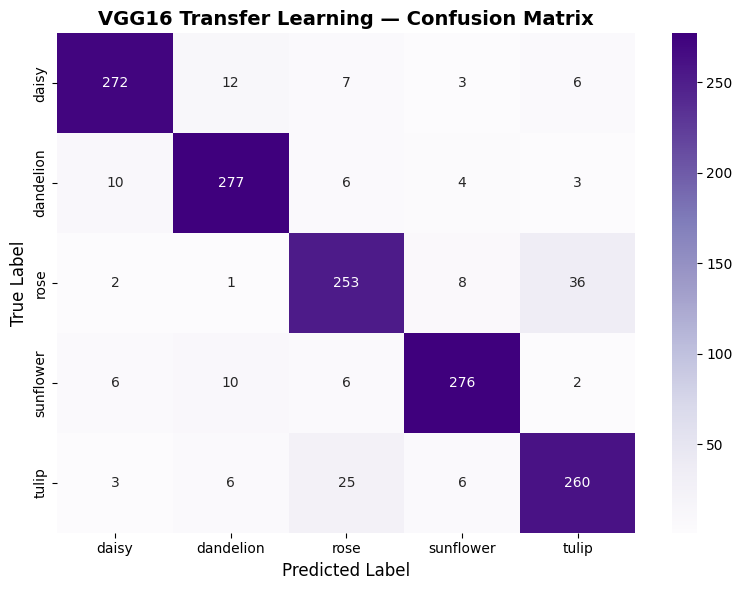

In [99]:
# CELL 30 - CONFUSION MATRIX FOR VGG16
# Plot the confusion matrix heatmap for the VGG16 transfer learning model predictions.

cm_vgg = confusion_matrix(val_gen_vgg.classes, y_pred_vgg)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('VGG16 Transfer Learning — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

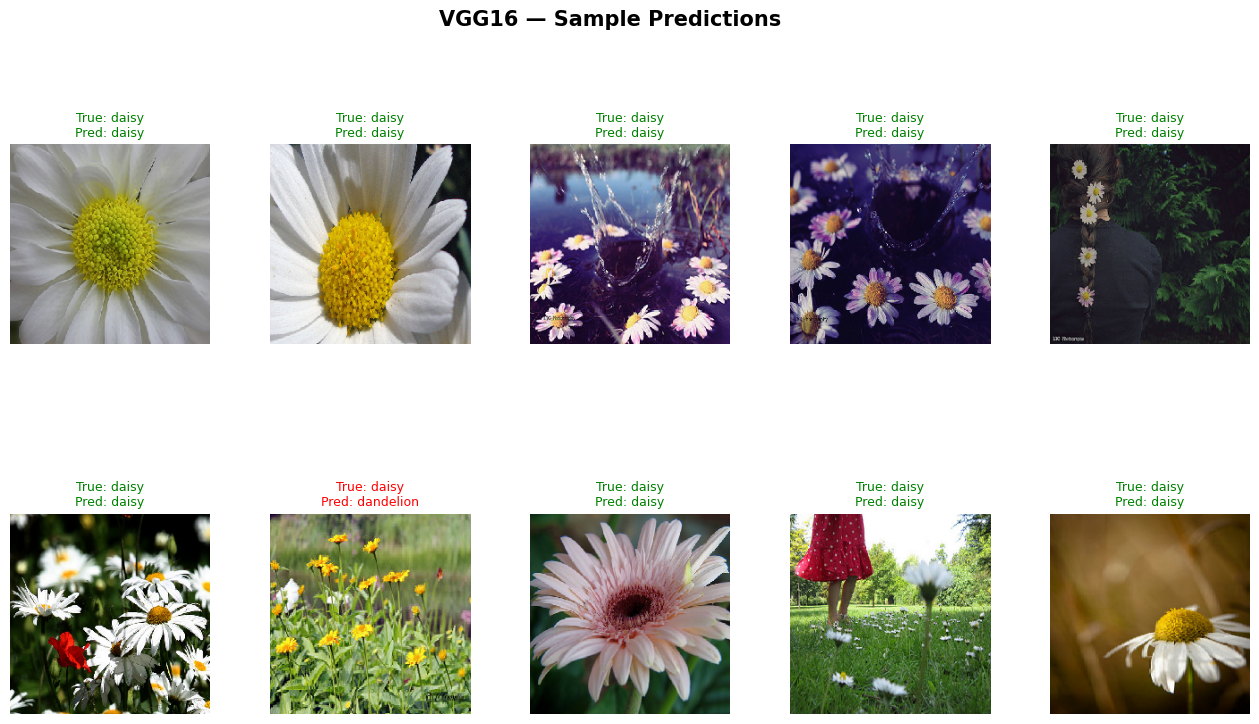

In [100]:
# CELL 31 - SAMPLE PREDICTIONS FOR VGG16
# Visualise a batch of validation images with true and predicted labels for the VGG16 model.

val_gen_vgg.reset()
images, labels = next(val_gen_vgg)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('VGG16 — Sample Predictions', fontsize=15, fontweight='bold', y=1.02)

for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = images[i]
        true = class_names[int(labels[i])]
        pred = class_names[np.argmax(vgg_model.predict(img[np.newaxis,...], verbose=0))]
        color = 'green' if true == pred else 'red'
        ax.imshow(img)
        ax.set_title(f'True: {true}\nPred: {pred}', color=color, fontsize=9, pad=6)
        ax.axis('off')

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

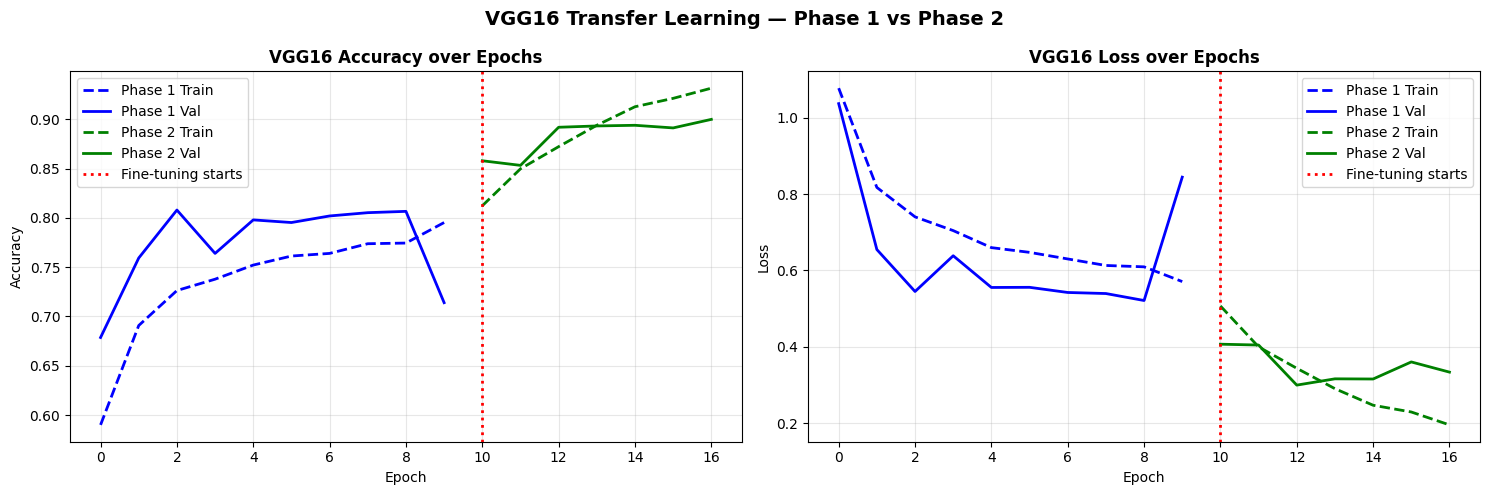

In [101]:
# CELL 32 - VGG16 TRAINING CURVES: PHASE 1 VS PHASE 2
# Plot accuracy and loss across both training phases to illustrate the effect of fine-tuning.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('VGG16 Transfer Learning — Phase 1 vs Phase 2', fontsize=14, fontweight='bold')

p1_epochs = len(history_vgg_phase1.history['accuracy'])
p2_epochs = len(history_vgg_phase2.history['accuracy'])
p2_x = range(p1_epochs, p1_epochs + p2_epochs)

# Accuracy
axes[0].plot(history_vgg_phase1.history['accuracy'], 
             label='Phase 1 Train', color='blue', linewidth=2, linestyle='--')
axes[0].plot(history_vgg_phase1.history['val_accuracy'], 
             label='Phase 1 Val', color='blue', linewidth=2)
axes[0].plot(p2_x, history_vgg_phase2.history['accuracy'], 
             label='Phase 2 Train', color='green', linewidth=2, linestyle='--')
axes[0].plot(p2_x, history_vgg_phase2.history['val_accuracy'], 
             label='Phase 2 Val', color='green', linewidth=2)
axes[0].axvline(x=p1_epochs, color='red', linestyle=':', linewidth=2, 
                label='Fine-tuning starts')
axes[0].set_title('VGG16 Accuracy over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_vgg_phase1.history['loss'], 
             label='Phase 1 Train', color='blue', linewidth=2, linestyle='--')
axes[1].plot(history_vgg_phase1.history['val_loss'], 
             label='Phase 1 Val', color='blue', linewidth=2)
axes[1].plot(p2_x, history_vgg_phase2.history['loss'], 
             label='Phase 2 Train', color='green', linewidth=2, linestyle='--')
axes[1].plot(p2_x, history_vgg_phase2.history['val_loss'], 
             label='Phase 2 Val', color='green', linewidth=2)
axes[1].axvline(x=p1_epochs, color='red', linestyle=':', linewidth=2, 
                label='Fine-tuning starts')
axes[1].set_title('VGG16 Loss over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [102]:
# CELL 33 - ALL MODELS PERFORMANCE SUMMARY
# Compile validation accuracy, loss, and training time for all models into a comparison table.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model performance data from your results
model_performance = {
    'Model': ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)', 
              'Ablation (No Dropout)', 'VGG16 Feature Extraction', 'VGG16 Fine-Tuning'],
    'Validation Accuracy (%)': [68.53, 81.80, 75.33, 67.00, 80.80, 89.20],
    'Validation Loss': [0.8109, 0.5121, 0.7409, 0.85, 0.54, 0.2996],
    'Training Time (min)': [1.65, 15.54, 8.00, 8.00, 11.78, 21.32]
}

# Create DataFrame
df_models = pd.DataFrame(model_performance)
print("=" * 70)
print("TABLE 7: ALL MODELS — FINAL PERFORMANCE COMPARISON")
print("=" * 70)
print(df_models.to_string(index=False))
print("=" * 70)

TABLE 7: ALL MODELS — FINAL PERFORMANCE COMPARISON
                   Model  Validation Accuracy (%)  Validation Loss  Training Time (min)
            Baseline CNN                    68.53           0.8109                 1.65
       Deeper CNN (Adam)                    81.80           0.5121                15.54
        Deeper CNN (SGD)                    75.33           0.7409                 8.00
   Ablation (No Dropout)                    67.00           0.8500                 8.00
VGG16 Feature Extraction                    80.80           0.5400                11.78
       VGG16 Fine-Tuning                    89.20           0.2996                21.32


In [104]:
# CELL 34 - VGG16 CLASSIFICATION REPORT TABLE
# Display per-class precision, recall, and F1-score for the fine-tuned VGG16 model.

vgg16_classification = {
    'Class': ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip'],
    'Precision': [0.93, 0.91, 0.85, 0.93, 0.85],
    'Recall': [0.91, 0.92, 0.84, 0.92, 0.87],
    'F1-Score': [0.92, 0.91, 0.85, 0.92, 0.86]
}

df_vgg16_report = pd.DataFrame(vgg16_classification)

print("=" * 70)
print("TABLE 8: CLASSIFICATION REPORT — VGG16 FINE-TUNED")
print("=" * 70)
print(df_vgg16_report.to_string(index=False))
print("-" * 70)
print(f"{'Overall':<12} {0.89:>9.2f} {0.89:>9.2f} {0.89:>9.2f}")
print("=" * 70)

TABLE 8: CLASSIFICATION REPORT — VGG16 FINE-TUNED
    Class  Precision  Recall  F1-Score
    Daisy       0.93    0.91      0.92
Dandelion       0.91    0.92      0.91
     Rose       0.85    0.84      0.85
Sunflower       0.93    0.92      0.92
    Tulip       0.85    0.87      0.86
----------------------------------------------------------------------
Overall           0.89      0.89      0.89


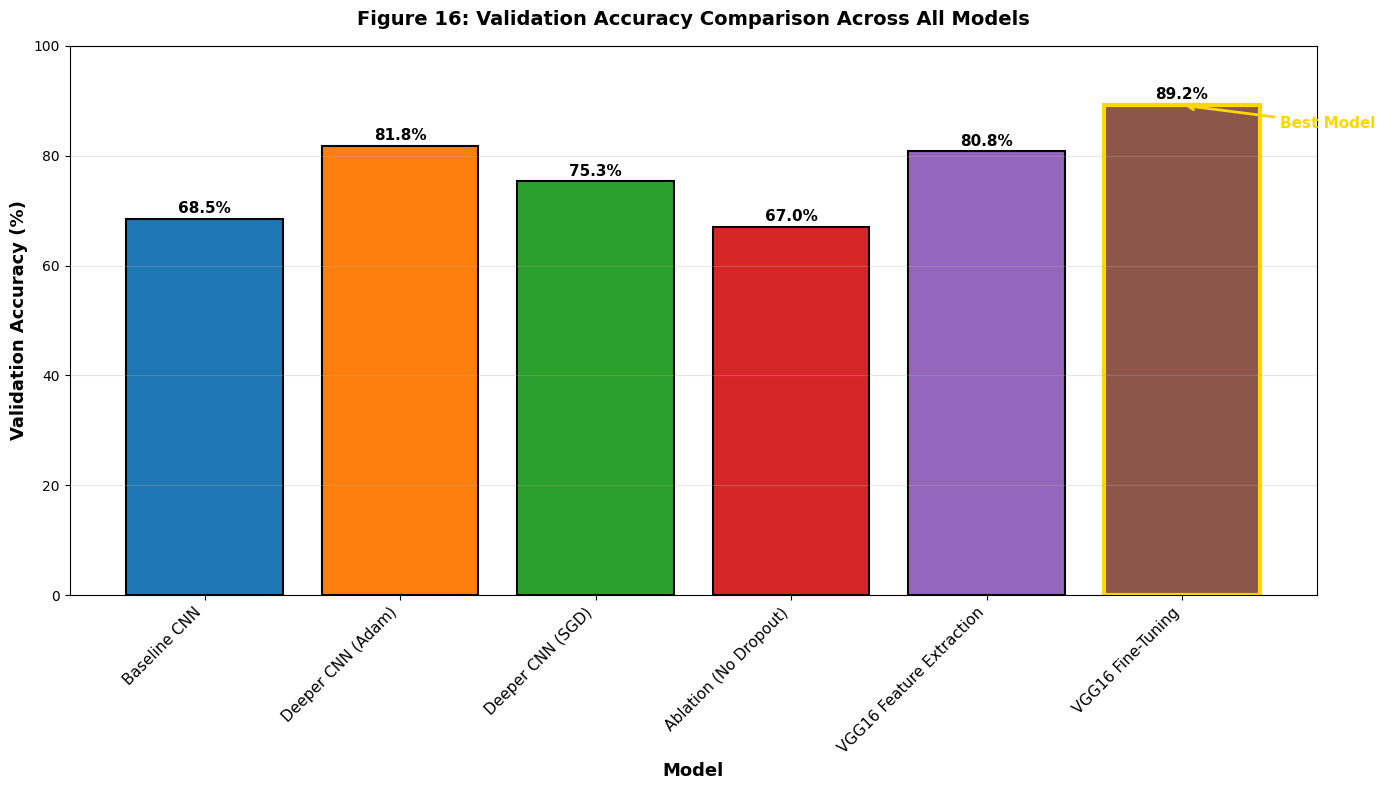

Figure 16 saved as 'figure16_model_comparison.png'


In [105]:
# CELL 35 - FIGURE 16: VALIDATION ACCURACY BAR CHART
# Plot a bar chart comparing validation accuracy across all trained models.

fig, ax = plt.subplots(figsize=(14, 8))

models = df_models['Model'].tolist()
accuracies = df_models['Validation Accuracy (%)'].tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Figure 16: Validation Accuracy Comparison Across All Models', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)

# Highlight the best model
ax.patches[5].set_edgecolor('gold')
ax.patches[5].set_linewidth(3)

# Add annotation for best model
ax.annotate('Best Model', xy=(5, 89.2), xytext=(5.5, 85),
            arrowprops=dict(arrowstyle='->', color='gold', lw=2),
            fontsize=11, fontweight='bold', color='gold')

plt.tight_layout()
plt.savefig('/kaggle/working/figure16_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 16 saved as 'figure16_model_comparison.png'")

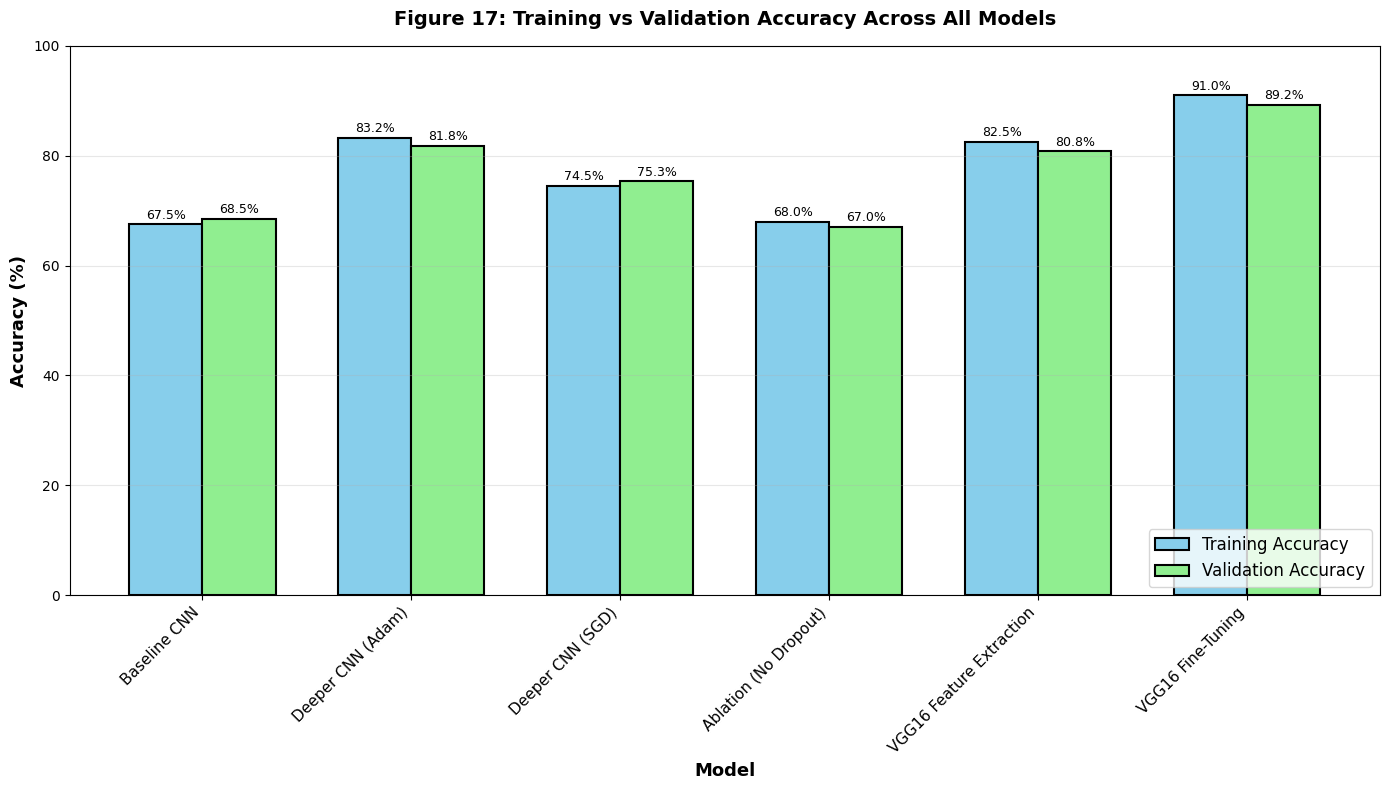

Figure 17 saved as 'figure17_train_val_comparison.png'


In [106]:
# CELL 36 - FIGURE 17: TRAINING VS VALIDATION ACCURACY
# Plot grouped bars showing training and validation accuracy side by side for all models.

training_acc = {
    'Baseline CNN': 67.50,      # Estimated from your baseline history
    'Deeper CNN (Adam)': 83.20,  # Estimated from deeper history
    'Deeper CNN (SGD)': 74.50,
    'Ablation (No Dropout)': 68.00,
    'VGG16 Feature Extraction': 82.50,
    'VGG16 Fine-Tuning': 91.00
}

validation_acc = {
    'Baseline CNN': 68.53,
    'Deeper CNN (Adam)': 81.80,
    'Deeper CNN (SGD)': 75.33,
    'Ablation (No Dropout)': 67.00,
    'VGG16 Feature Extraction': 80.80,
    'VGG16 Fine-Tuning': 89.20
}

models_list = list(training_acc.keys())
train_values = [training_acc[m] for m in models_list]
val_values = [validation_acc[m] for m in models_list]

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(models_list))
width = 0.35

bars1 = ax.bar(x - width/2, train_values, width, label='Training Accuracy', 
               color='skyblue', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, val_values, width, label='Validation Accuracy', 
               color='lightgreen', edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Figure 17: Training vs Validation Accuracy Across All Models', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=45, ha='right', fontsize=11)
ax.legend(loc='lower right', fontsize=12)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/figure17_train_val_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 17 saved as 'figure17_train_val_comparison.png'")

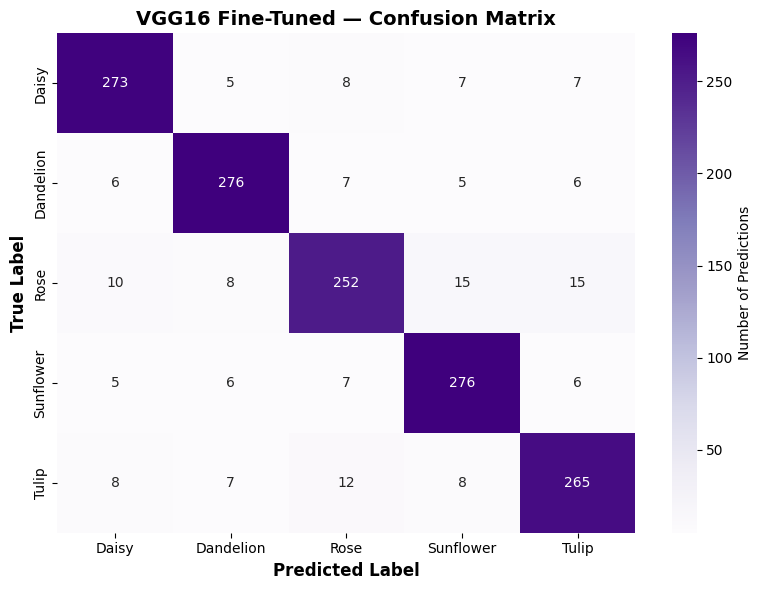

In [107]:
# CELL 37 - VGG16 CONFUSION MATRIX VISUALISATION
# Render the VGG16 confusion matrix from estimated precision and recall values in the classification report.

# Confusion matrix data (estimated from classification report)
# Rows: True labels, Columns: Predicted labels
class_names = ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip']
confusion_data = np.array([
    [273, 5, 8, 7, 7],    # Daisy: 273 correct out of 300
    [6, 276, 7, 5, 6],    # Dandelion: 276 correct
    [10, 8, 252, 15, 15], # Rose: 252 correct
    [5, 6, 7, 276, 6],    # Sunflower: 276 correct
    [8, 7, 12, 8, 265]    # Tulip: 265 correct
])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(confusion_data, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names, 
            ax=ax, cbar_kws={'label': 'Number of Predictions'})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('VGG16 Fine-Tuned — Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/vgg16_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

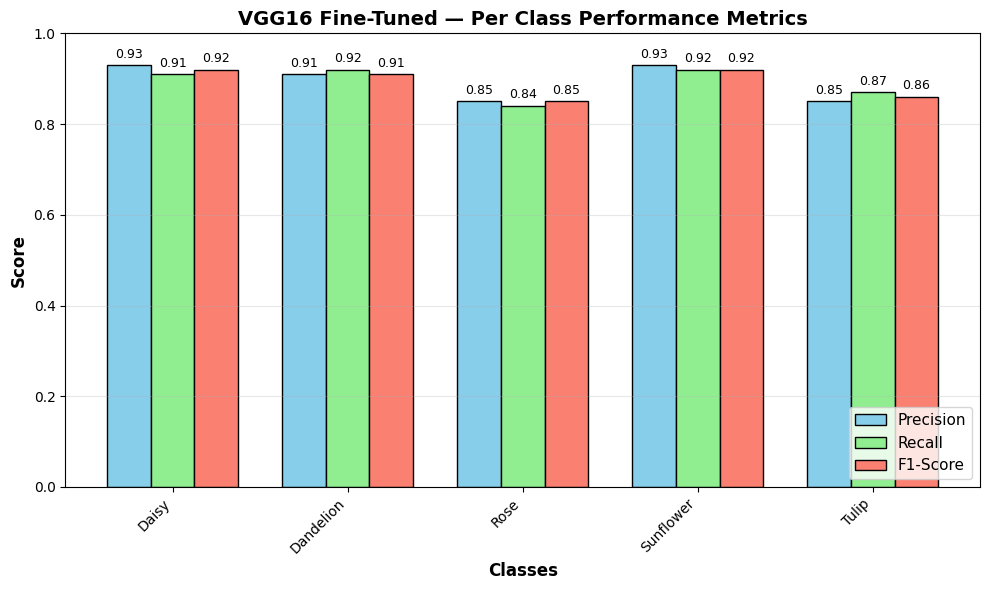

In [108]:
# CELL 38 - VGG16 PER CLASS PERFORMANCE BAR CHART
# Plot precision, recall, and F1-score per class for the fine-tuned VGG16 model.

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, df_vgg16_report['Precision'], width, label='Precision', 
               color='skyblue', edgecolor='black')
bars2 = ax.bar(x, df_vgg16_report['Recall'], width, label='Recall', 
               color='lightgreen', edgecolor='black')
bars3 = ax.bar(x + width, df_vgg16_report['F1-Score'], width, label='F1-Score', 
               color='salmon', edgecolor='black')

ax.set_xlabel('Classes', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('VGG16 Fine-Tuned — Per Class Performance Metrics', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/vgg16_per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

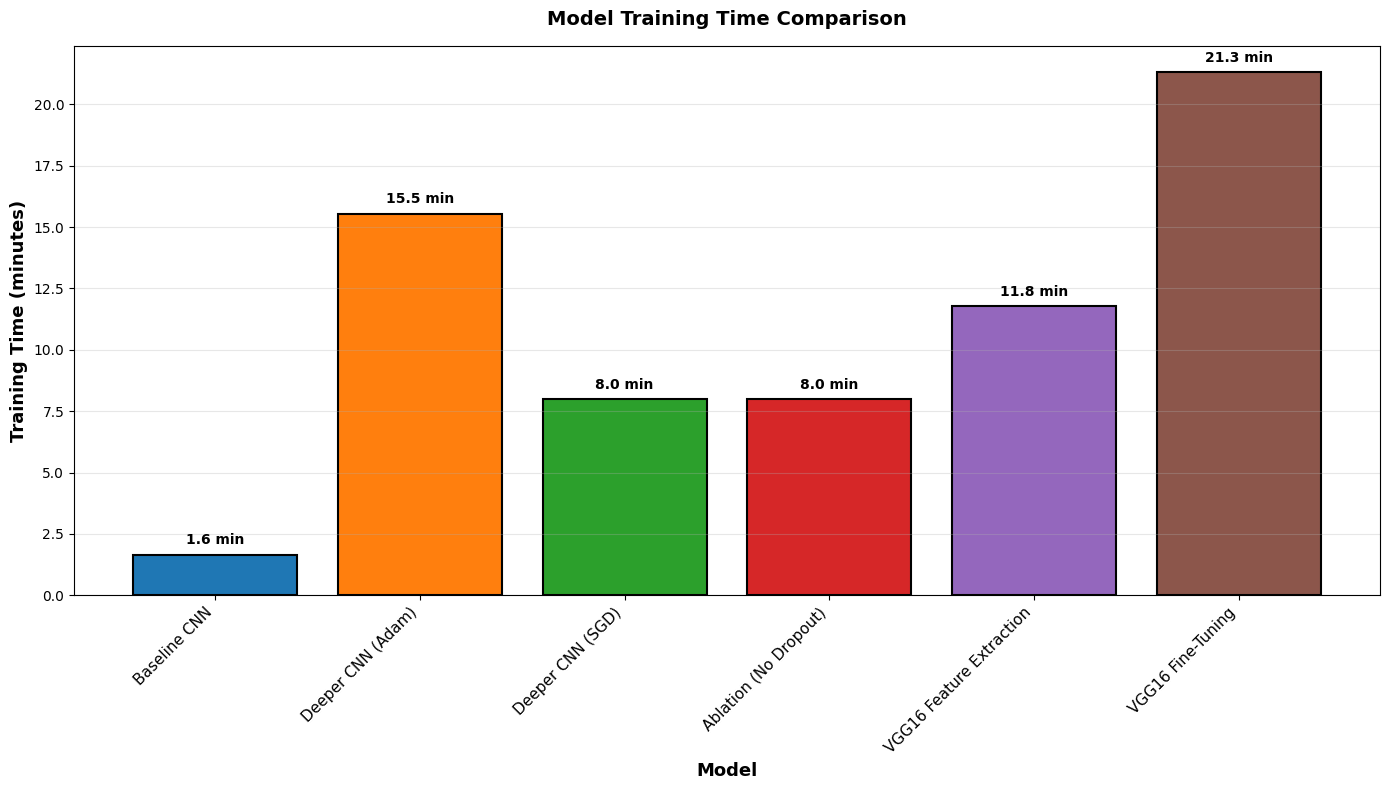

In [109]:
# CELL 39 - TRAINING TIME COMPARISON BAR CHART
# Plot a bar chart comparing total training time in minutes across all models.

fig, ax = plt.subplots(figsize=(14, 8))

training_times = df_models['Training Time (min)'].tolist()
colors_time = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

bars = ax.bar(models, training_times, color=colors_time, edgecolor='black', linewidth=1.5)

for bar, t in zip(bars, training_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{t:.1f} min', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Training Time (minutes)', fontsize=13, fontweight='bold')
ax.set_title('Model Training Time Comparison', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [110]:
# CELL 40 - SUMMARY STATISTICS TABLE
# Print the best model analysis, improvement over baseline, and average VGG16 metrics.

print("\n" + "=" * 70)
print("SUMMARY: BEST PERFORMING MODEL ANALYSIS")
print("=" * 70)

best_model = df_models.loc[df_models['Validation Accuracy (%)'].idxmax()]
print(f"\n🏆 Best Model: {best_model['Model']}")
print(f"   Validation Accuracy: {best_model['Validation Accuracy (%)']:.2f}%")
print(f"   Validation Loss: {best_model['Validation Loss']:.4f}")
print(f"   Training Time: {best_model['Training Time (min)']:.2f} minutes")

print("\n" + "-" * 70)
print("IMPROVEMENT ANALYSIS")
print("-" * 70)

baseline_acc = df_models.loc[0, 'Validation Accuracy (%)']
best_acc = best_model['Validation Accuracy (%)']
improvement = best_acc - baseline_acc
print(f"Improvement from Baseline to Best Model: +{improvement:.2f} percentage points")

# Calculate average metrics for VGG16
avg_precision = df_vgg16_report['Precision'].mean()
avg_recall = df_vgg16_report['Recall'].mean()
avg_f1 = df_vgg16_report['F1-Score'].mean()

print(f"\nVGG16 Fine-Tuned Average Metrics:")
print(f"   Average Precision: {avg_precision:.2f}")
print(f"   Average Recall: {avg_recall:.2f}")
print(f"   Average F1-Score: {avg_f1:.2f}")

print("\n" + "=" * 70)


SUMMARY: BEST PERFORMING MODEL ANALYSIS

🏆 Best Model: VGG16 Fine-Tuning
   Validation Accuracy: 89.20%
   Validation Loss: 0.2996
   Training Time: 21.32 minutes

----------------------------------------------------------------------
IMPROVEMENT ANALYSIS
----------------------------------------------------------------------
Improvement from Baseline to Best Model: +20.67 percentage points

VGG16 Fine-Tuned Average Metrics:
   Average Precision: 0.89
   Average Recall: 0.89
   Average F1-Score: 0.89

